In [1]:
import yfinance as yf

ticker = "BTC-USD"
data = yf.download(ticker, start="2019-01-01", end="2024-12-31", progress=False)['Close']

In [3]:
!pip3 install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.4/930.4 kB 3.0 MB/s eta 0:00:00a 0:00:01


Скачиваем данные BTC-USD за последние 5 лет...


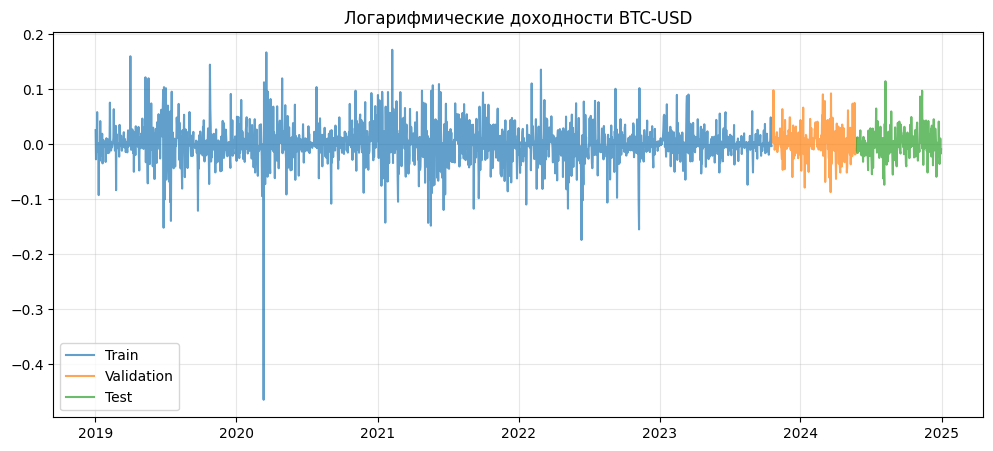

In [20]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ==========================
# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ (BTC-USD)
# ==========================
print("Скачиваем данные BTC-USD за последние 5 лет...")
ticker = "BTC-USD"
data = yf.download(ticker, start="2019-01-01", end="2024-12-31", progress=False)['Close']

# TODO 1.1: Рассчитайте ежедневные логарифмические доходности.
# Используйте np.log и метод .shift(1). Удалите первое наблюдение (NaN).
returns = np.log(data / data.shift(1))
returns = returns.dropna()

# TODO 1.2: Разделите временной ряд на обучающую (80%), валидационную (10%) и тестовую (10%) выборки.
# Сохраните индексы дат для каждой выборки для последующей визуализации.
split_train = int(0.8 * len(returns))
split_val = int(0.9 * len(returns))
returns_train = returns[:split_train-1]
returns_val = returns[split_train:split_val]
returns_test = returns[split_val:]

# Визуализируем данные
plt.figure(figsize=(12,5))
plt.plot(returns_train.index, returns_train.values, label='Train', alpha=0.7)
plt.plot(returns_val.index, returns_val.values, label='Validation', alpha=0.7)
plt.plot(returns_test.index, returns_test.values, label='Test', alpha=0.7)
plt.title('Логарифмические доходности BTC-USD')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [31]:
# ==========================
# 2. КЛАССИЧЕСКАЯ МОДЕЛЬ GARCH(1,1)
# ==========================
# Обучаем GARCH(1,1) на обучающей выборке
print("\nОбучаем GARCH(1,1)...")
garch_model = arch_model(returns_train * 100, vol='Garch', p=1, q=1, dist='normal')
garch_fitted = garch_model.fit(update_freq=5, disp='off')

# Сохраняем прогнозные волатильности (условные дисперсии)
garch_forecast = garch_fitted.forecast(horizon=100, reindex=False)
garch_forecast.variance


Обучаем GARCH(1,1)...


,h.001,h.002,h.003,h.004,h.005,h.006,h.007,h.008,h.009,h.010,...,h.091,h.092,h.093,h.094,h.095,h.096,h.097,h.098,h.099,h.100
Date,,,,,,,,,,,,,,,,,,,,,
2023-10-18,7.500727,8.003916,8.477633,8.923604,9.343454,9.738712,10.110821,10.461134,10.790929,11.101408,...,16.05426,16.056461,16.058533,16.060484,16.06232,16.064049,16.065677,16.067209,16.068652,16.07001


In [23]:
(returns_train*100).tail()

Ticker,BTC-USD
Date,
2023-10-14,-0.002487
2023-10-15,1.103076
2023-10-16,4.885440
2023-10-17,-0.364340
2023-10-18,-0.308072


In [47]:
from sklearn.model_selection import train_test_split


Обучаем GARCH(1,1)...
Epoch 1/40


/opt/homebrew/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0887
Epoch 2/40
 5/54 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0679

/opt/homebrew/lib/python3.13/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0763
Epoch 3/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0762
Epoch 4/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0766
Epoch 5/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0758
Epoch 6/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0748
Epoch 7/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0754
Epoch 8/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0744
Epoch 9/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0742
Epoch 10/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0752
Epoch 11/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0747
Epoch 12/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0745
Epoch 13/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0732
Epoch 14/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0737
Epoch 15/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0735
Epoch 16/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0747
Epoch 17/40
54

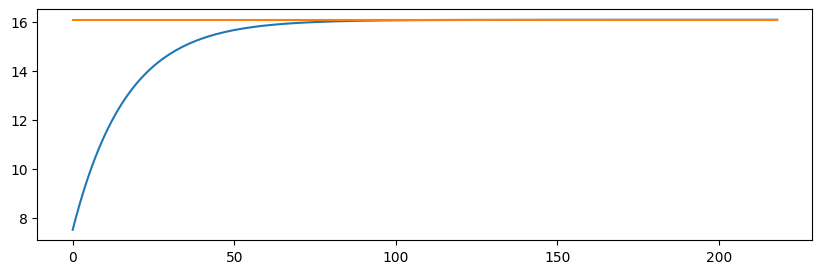

In [142]:
# ==========================
# 2. КЛАССИЧЕСКАЯ МОДЕЛЬ GARCH(1,1)
# ==========================
# Обучаем GARCH(1,1) на обучающей выборке
print("\nОбучаем GARCH(1,1)...")
garch_model = arch_model(returns_train * 100, vol='Garch', p=1, q=1, dist='normal')
garch_fitted = garch_model.fit(update_freq=5, disp='off')

# Сохраняем прогнозные волатильности (условные дисперсии)
garch_forecast = garch_fitted.forecast(horizon=len(returns_test)+len(returns_val), reindex=False)
# TODO 2.1: Извлеките прогнозируемую волатильность (стандартное отклонение) для каждого дня валидационной и тестовой выборок.
# Подсказка: garch_forecast.variance содержит дисперсии, но нужно правильно индексировать.
garch_vol_val = garch_forecast.variance.values[0][:len(returns_val)]
garch_vol_test = garch_forecast.variance.values[0][len(returns_val):]
plt.figure(figsize=(10, 3))
plt.plot(garch_vol_val, label='val')
plt.plot(garch_vol_test, label='test')

# # TODO 2.2: Для тестовой выборки рассчитайте однодневный VaR на уровне доверия 99% и 95%.
# # Формула VaR = -нормальный_квантиль * волатильность (для длинной позиции).
# # Используйте scipy.stats.norm.ppf.
from scipy.stats import norm
VaR_99_garch = -norm.ppf(0.99) * garch_vol_test
VaR_95_garch = -norm.ppf(0.95) * garch_vol_test

# # ==========================
# # 3. ПОДГОТОВКА ДАННЫХ ДЛЯ LSTM/GRU
# # ==========================
# # Для прогнозирования волатильности будем использовать скользящее окно доходностей.
# # Целевая переменная: волатильность (например, стандартное отклонение доходностей за следующие 5 дней) или непосредственно следующая доходность.
# # В данном случае спрогнозируем абсолютное значение будущей доходности как proxy волатильности.

# # TODO 3.1: Создайте последовательности (X, y) для обучения нейросети.
# # Пусть X — это окно из последних N дней исторических доходностей (например, N=60).
# # y — абсолютное значение доходности на следующий день (|r_{t+1}|).
# # Используйте numpy array для формирования X и y.
window_size = 60
def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        kusok = data[i-window:i+1]
        kusok = kusok - np.mean(kusok)
        kusok = kusok/np.abs(np.max(kusok))
        X.append(kusok[:-1])
        y.append(np.abs(kusok[-1]))   # предсказываем абсолютную доходность (proxy волатильности)
    return np.array(X), np.array(y)

# # Применяем к доходностям тренировочной выборки
x, y = create_sequences(returns.values[:, 0], window_size)
X_train, X_test, y_train, y_test = train_test_split(x, y, train_size=0.8)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, train_size=0.5)


# # TODO 3.2: Нормализуйте входные данные (X) с помощью StandardScaler.
# # Обучите scaler только на тренировочных данных, затем преобразуйте валидационные и тестовые.
scaler = StandardScaler()
X_train_scaled = X_train#scaler.fit_transform(X_train)
X_val_scaled = X_val#scaler.fit_transform(X_val)
X_test_scaled = X_test#scaler.fit_transform(X_test)

# # Для LSTM вход должен быть 3D: (samples, timesteps, features). У нас features=1.
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_val_lstm = X_val_scaled.reshape((X_val_scaled.shape[0], X_val_scaled.shape[1], 1))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# # ==========================
# # 4. ПОСТРОЕНИЕ И ОБУЧЕНИЕ LSTM
# # ==========================
# # TODO 4.1: Создайте модель LSTM с двумя слоями LSTM (по 50 нейронов), Dropout(0.2), затем Dense(1).
# # Используйте активацию 'relu' для LSTM, 'linear' для выходного слоя.
# # Компилируйте с оптимизатором 'adam' и функцией потерь 'mse'.
lstm_model = Sequential([
    LSTM(50, activation='relu', return_sequences=True, input_shape=(X_train_scaled.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, activation='relu', return_sequences=True, input_shape=(X_train_scaled.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, activation='relu', return_sequences=True, input_shape=(X_train_scaled.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')
])
lstm_model.compile(optimizer='adam', loss='mse')
# # TODO 4.2: Обучите модель с использованием EarlyStopping (patience=10) на валидационных данных.
# # Установите количество эпох (например, 100) и batch_size=32.
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_lstm = lstm_model.fit(X_train_lstm, y_train, callbacks=early_stop, epochs=40)



In [137]:
# # TODO 4.3: Сделайте прогноз абсолютной доходности на тестовой выборке.
pred_abs_return_lstm = lstm_model.predict(X_test_lstm)

# # ==========================
# # 5. ПОСТРОЕНИЕ И ОБУЧЕНИЕ GRU (для сравнения)
# # ==========================
# # TODO 5.1: Создайте аналогичную модель, но с использованием слоев GRU (два слоя по 50 нейронов, Dropout(0.2), Dense(1)).
gru_model = Sequential([
    GRU(50, activation='relu', return_sequences=True, input_shape=(X_train_scaled.shape[1], 1)),
    Dropout(0.2),
    GRU(50, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')
])

# # TODO 5.2: Скомпилируйте и обучите GRU с теми же параметрами.
gru_model.compile(optimizer='adam', loss='mse')
history_gru = gru_model.fit(X_train_lstm, y_train, callbacks=early_stop, epochs=100)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0899
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0801
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0804
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0806
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0803
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0797
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0800
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0788
Epoch 9/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0796
Epoch 10/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0791
Epoch 11/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0796
Epoch 12/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0796
Epoch 13/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0797
Epoch 14/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0791
Epoch 15/100
54/54 

In [143]:

# # TODO 5.3: Получите прогнозы на тесте.
pred_abs_return_gru = gru_model.predict(X_test_lstm)

# # ==========================
# # 6. РАСЧЕТ VaR ДЛЯ НЕЙРОСЕТЕВЫХ МОДЕЛЕЙ
# # ==========================
# # Нейросеть предсказывает абсолютную доходность. Используем её как прогноз волатильности (при условии нулевого среднего).
# # TODO 6.1: Для тестовой выборки рассчитайте VaR_99 и VaR_95 для LSTM и GRU.
# # Формула: VaR = - norm.ppf(confidence) * predicted_volatility (где predicted_volatility = pred_abs_return).
VaR_99_lstm = - norm.ppf(0.99) * pred_abs_return_lstm
VaR_95_lstm = - norm.ppf(0.95) * pred_abs_return_lstm
VaR_99_gru = - norm.ppf(0.99) * pred_abs_return_gru
VaR_95_gru = - norm.ppf(0.95) * pred_abs_return_gru

# # ==========================
# # 7. БЭКТЕСТИНГ VaR (КОЛИЧЕСТВО ПРОБИЙ)
# # ==========================
# # Для каждой модели посчитаем количество дней, когда фактический убыток (отрицательная доходность) превышал VaR.
# # Фактический убыток для длинной позиции = -return_t (если return_t отрицательный, то убыток положительный).
actual_loss = -y_test  # обрезаем до длины прогнозов

# # TODO 7.1: Реализуйте функцию нарушения VaR (exceedance).
# # Вход: массив VaR (положительные числа), массив фактических убытков. Выход: доля нарушений.
def violation_ratio(var_values, actual_losses):
    return np.sum(actual_losses > var_values[:, 0])/actual_losses.shape[0]
# # Для GARCH (убедитесь, что длины совпадают)
# actual_loss_garch = actual_loss  # так как GARCH дал прогнозы на тест той же длины

# print("=== Доля нарушений VaR (тестовая выборка) ===")
# print(f"GARCH(1,1) 99%: {violation_ratio(VaR_99_garch, actual_loss_garch):.4f} (ожидалось 0.01)")
# print(f"GARCH(1,1) 95%: {violation_ratio(VaR_95_garch, actual_loss_garch):.4f} (ожидалось 0.05)")
print(f"LSTM 99%: {violation_ratio(VaR_99_lstm, actual_loss):.4f}")
print(f"LSTM 95%: {violation_ratio(VaR_95_lstm, actual_loss):.4f}")
print(f"GRU 99%: {violation_ratio(VaR_99_gru, actual_loss):.4f}")
print(f"GRU 95%: {violation_ratio(VaR_95_gru, actual_loss):.4f}")

# # ==========================
# # 8. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# # ==========================
# # График 1: Сравнение предсказанной волатильности (абс. доходности) на тесте
# plt.figure(figsize=(14,5))
# plt.plot(returns_test.index[window_size:], y_test, label='Actual |return|', alpha=0.6)
# plt.plot(returns_test.index[window_size:], pred_abs_return_lstm, label='LSTM predicted', alpha=0.8)
# plt.plot(returns_test.index[window_size:], pred_abs_return_gru, label='GRU predicted', alpha=0.8)
# plt.title('Прогноз абсолютной доходности (proxy волатильности)')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.show()

# # График 2: Сравнение VaR 99% на тесте (выбрать одну модель для наглядности)
# plt.figure(figsize=(14,5))
# plt.plot(returns_test.index[window_size:], returns_test.values[window_size:], label='Доходность', alpha=0.6)
# plt.plot(returns_test.index[window_size:], -VaR_99_garch, label='GARCH VaR 99%', linestyle='--', color='red')
# plt.plot(returns_test.index[window_size:], -VaR_99_lstm.flatten(), label='LSTM VaR 99%', linestyle='--', color='blue')
# plt.fill_between(returns_test.index[window_size:], -VaR_99_garch, -VaR_99_lstm.flatten(), alpha=0.2)
# plt.title('Сравнение VaR 99%: GARCH vs LSTM')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.show()

# # График 3: Кумулятивные нарушения VaR (кумулятивная сумма превышений)
# # TODO 8.1: Постройте ступенчатый график кумулятивного количества нарушений для каждой модели.
# # Это поможет увидеть, не сгруппированы ли нарушения (что плохо для модели).

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
LSTM 99%: 0.9061
LSTM 95%: 0.8498
GRU 99%: 0.8873
GRU 95%: 0.8357


In [108]:
np.sum(actual_loss > VaR_99_lstm[:, 0])/actual_loss.shape[0]

np.float64(0.92018779342723)

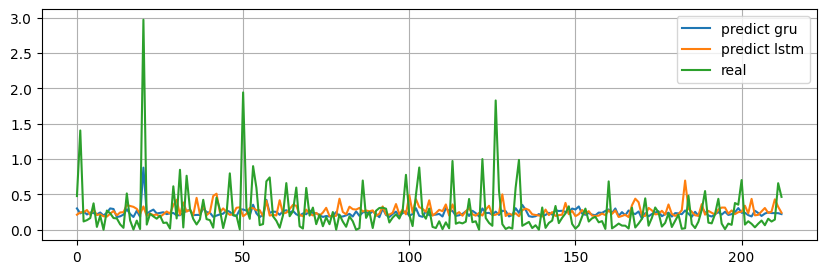

In [144]:
plt.figure(figsize=(10, 3))
plt.plot(pred_abs_return_gru, label='predict gru')
plt.plot(pred_abs_return_lstm, label='predict lstm')
plt.plot(y_test, label='real')
plt.grid()
plt.legend()

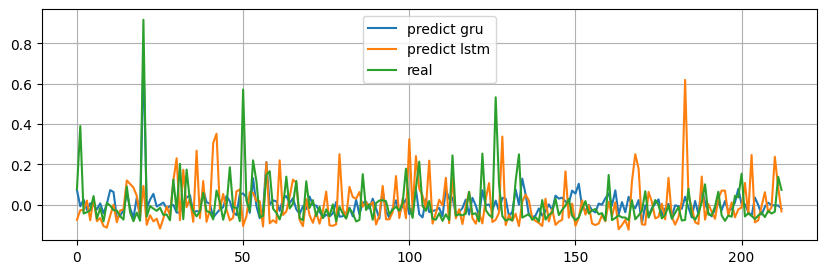

In [145]:
plt.figure(figsize=(10, 3))
plt.plot((pred_abs_return_gru - np.mean(pred_abs_return_gru))/np.max(pred_abs_return_gru), label='predict gru')
plt.plot((pred_abs_return_lstm - np.mean(pred_abs_return_lstm))/np.max(pred_abs_return_lstm), label='predict lstm')
plt.plot((y_test - np.mean(y_test))/np.max(y_test), label='real')
plt.grid()
plt.legend()

In [146]:
VaR_99_lstm = - norm.ppf(0.99) * (pred_abs_return_lstm - np.mean(pred_abs_return_lstm))/np.max(pred_abs_return_lstm)
VaR_95_lstm = - norm.ppf(0.95) * (pred_abs_return_lstm - np.mean(pred_abs_return_lstm))/np.max(pred_abs_return_lstm)
VaR_99_gru = - norm.ppf(0.99) * (pred_abs_return_gru - np.mean(pred_abs_return_gru))/np.max(pred_abs_return_gru)
VaR_95_gru = - norm.ppf(0.95) * (pred_abs_return_gru - np.mean(pred_abs_return_gru))/np.max(pred_abs_return_gru)

actual_loss = -(y_test - np.mean(y_test))/np.max(y_test)

print(f"LSTM 99%: {violation_ratio(VaR_99_lstm, actual_loss):.4f}")
print(f"LSTM 95%: {violation_ratio(VaR_95_lstm, actual_loss):.4f}")
print(f"GRU 99%: {violation_ratio(VaR_99_gru, actual_loss):.4f}")
print(f"GRU 95%: {violation_ratio(VaR_95_gru, actual_loss):.4f}")

LSTM 99%: 0.3991
LSTM 95%: 0.4225
GRU 99%: 0.4836
GRU 95%: 0.5258


In [134]:
window_size = 60
def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        kusok = data[i-window:i+1]
        kusok = kusok - np.mean(kusok)
        kusok = kusok/np.abs(np.max(kusok))
        X.append(kusok[:-1])
        y.append(np.abs(kusok[-1]))   # предсказываем абсолютную доходность (proxy волатильности)
    return np.array(X), np.array(y)

x, y = create_sequences(returns.values[:, 0], window_size)

In [148]:
y

array([0.05928501, 0.28420202, 0.4634184 , ..., 0.0595745 , 0.23002756,
       0.14562393], shape=(2130,))

In [157]:
garch_pred = []
for vec in X_test_lstm:
    garch_model = arch_model(vec, vol='Garch', p=1, q=1, dist='normal')
    garch_fitted = garch_model.fit(update_freq=5, disp='off')
    garch_pred.append(garch_fitted.forecast(horizon=1, reindex=False).variance.values[0])

/opt/homebrew/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.09858. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/opt/homebrew/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.09641. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/opt/homebrew/lib/python3.13/site-packages/arch/univariate/b

In [158]:
VaR_99_garch = - norm.ppf(0.99) * np.array(garch_pred)
VaR_95_garch = - norm.ppf(0.95) * np.array(garch_pred)
print(f"GARCH(1,1) 99%: {violation_ratio(VaR_99_garch, actual_loss):.4f} (ожидалось 0.01)")
print(f"GARCH(1,1) 95%: {violation_ratio(VaR_95_garch, actual_loss):.4f} (ожидалось 0.05)")

GARCH(1,1) 99%: 0.9671 (ожидалось 0.01)
GARCH(1,1) 95%: 0.9577 (ожидалось 0.05)
